### Running The Pipeline

In [1]:
import sys
sys.path.append("..")

from src.ml.train import run_training_pipeline

metrics = run_training_pipeline()
print("\nFinal Metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\DC\miniconda3\envs\python_ml\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\DC\miniconda3\envs\python_ml\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\DC\miniconda3\envs\python_ml\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File 

AttributeError: _ARRAY_API not found

INFO:src.ml.train:Loading and processing data ...
INFO:src.data.loader:Loading dataset from C:\Users\DC\realtyiq\data\raw\AmesHousing.csv...
INFO:src.data.loader:Loaded 2,930 rows and 82 columns.
INFO:src.data.loader:Column validation passed. All required columns are present.
INFO:src.data.cleaner:Starting data cleaning pipeline ...
INFO:src.data.cleaner:Dropped 7 columns: ['Order', 'PID', 'Misc Feature', 'Misc Val', 'Pool QC', 'Fence', 'Alley']
INFO:src.data.cleaner:Filled numeric null in 'Lot Frontage' with median=68.00
INFO:src.data.cleaner:Filled numeric null in 'Garage Yr Blt' with median=1979.00
INFO:src.data.cleaner:Filled categorical null in 'Electrical' with mode='SBrkr'
INFO:src.data.cleaner:Removed 5 outlier rows. Remaining: 2,925
INFO:src.data.cleaner:Data cleaning completed. Final shape: (2925, 75)
INFO:src.data.features:Starting feature engineering...
INFO:src.data.features:Label-encoded 36 categorical columns.
INFO:src.data.features:Feature engineering complete. Shape: (

[0]	validation_0-rmse:0.39860
[100]	validation_0-rmse:0.09805
[200]	validation_0-rmse:0.09509
[300]	validation_0-rmse:0.09474
[313]	validation_0-rmse:0.09478


INFO:src.ml.train:Best iteration: 264
INFO:src.ml.evaluate:Saved actual_vs_predicted.png
INFO:src.ml.train:
────────────────────────────────────────
INFO:src.ml.train:FINAL METRICS
INFO:src.ml.train:────────────────────────────────────────
INFO:src.ml.train:  rmse                      20061.31
INFO:src.ml.train:  mae                       12610.31
INFO:src.ml.train:  r2                        0.94
INFO:src.ml.train:  mape                      6.94
INFO:src.ml.train:  cv_r2_mean                0.9057
INFO:src.ml.train:  cv_r2_std                 0.0076
INFO:src.ml.train:  best_iteration            264
INFO:src.ml.train:  train_rows                2340
INFO:src.ml.train:  test_rows                 585
INFO:src.ml.train:  n_features                87
INFO:src.ml.train:Generating SHAP and feature importance plots ...
INFO:src.ml.evaluate:Saved feature_importance.png
INFO:src.ml.evaluate:Computing SHAP values (this may take ~30 seconds) ...
INFO:src.ml.evaluate:Saved shap_summary.png
INFO:s


Final Metrics:
  rmse: 20061.31
  mae: 12610.31
  r2: 0.94
  mape: 6.94
  cv_r2_mean: 0.9057
  cv_r2_std: 0.0076
  best_iteration: 264
  train_rows: 2340
  test_rows: 585
  n_features: 87


### SHAP summary plot

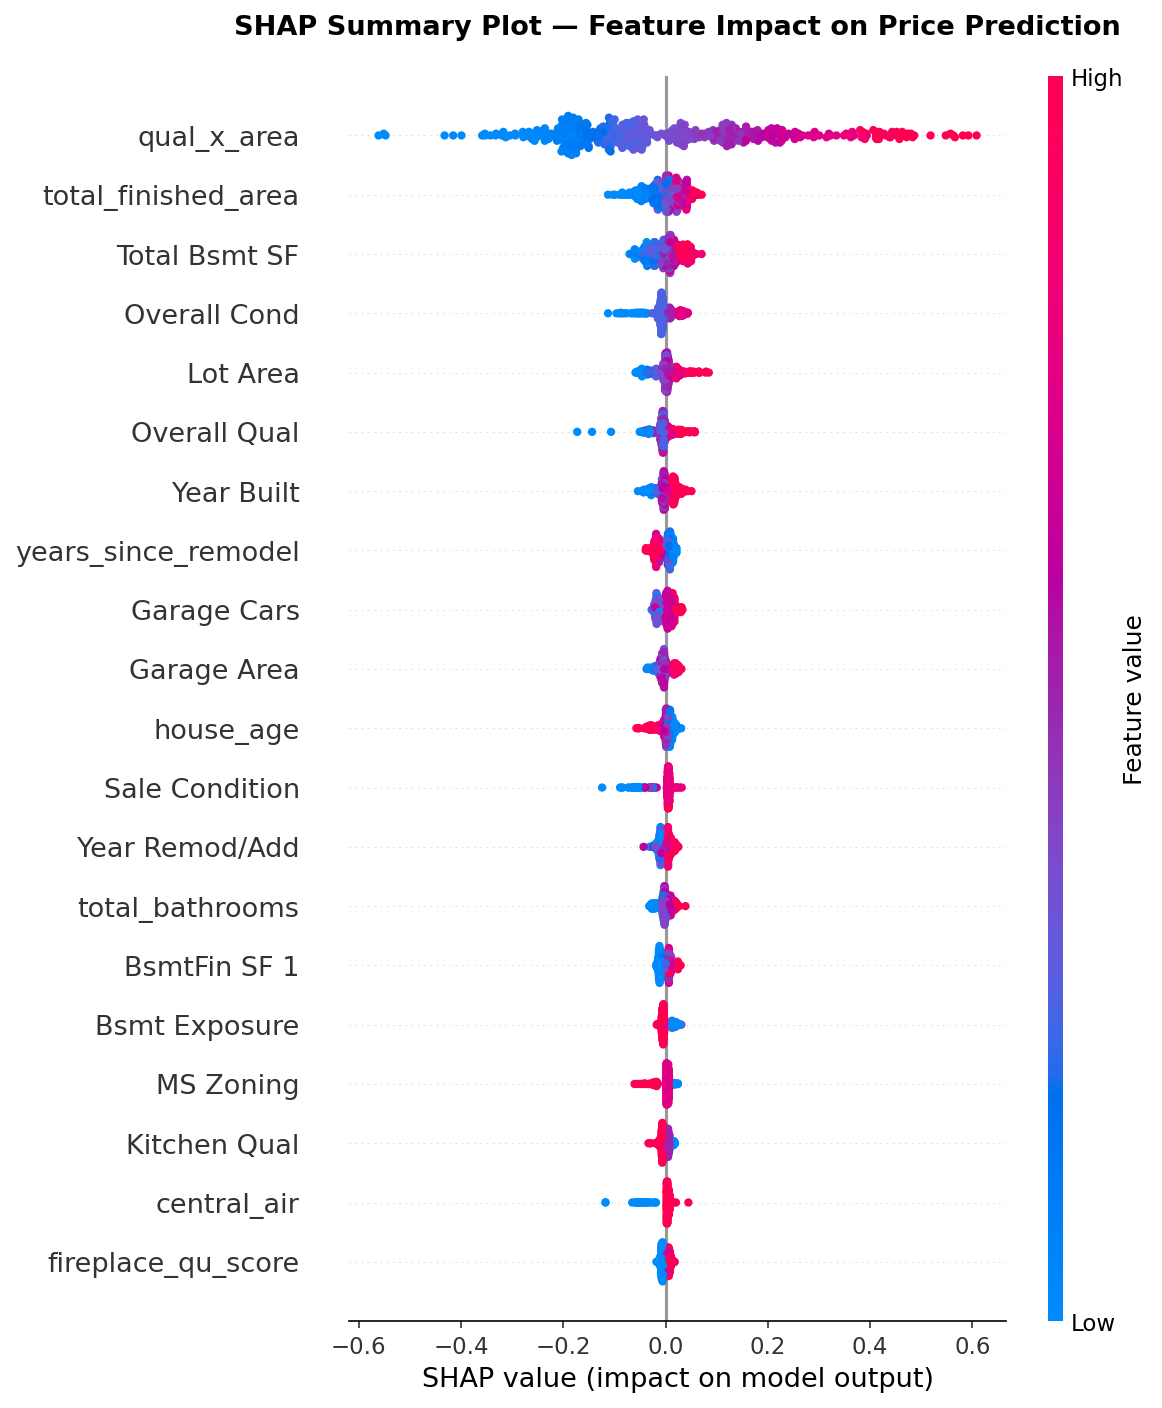

In [2]:
from IPython.display import Image

Image("../models/plots/shap_summary.png", width=800)

### Actual vs predicted

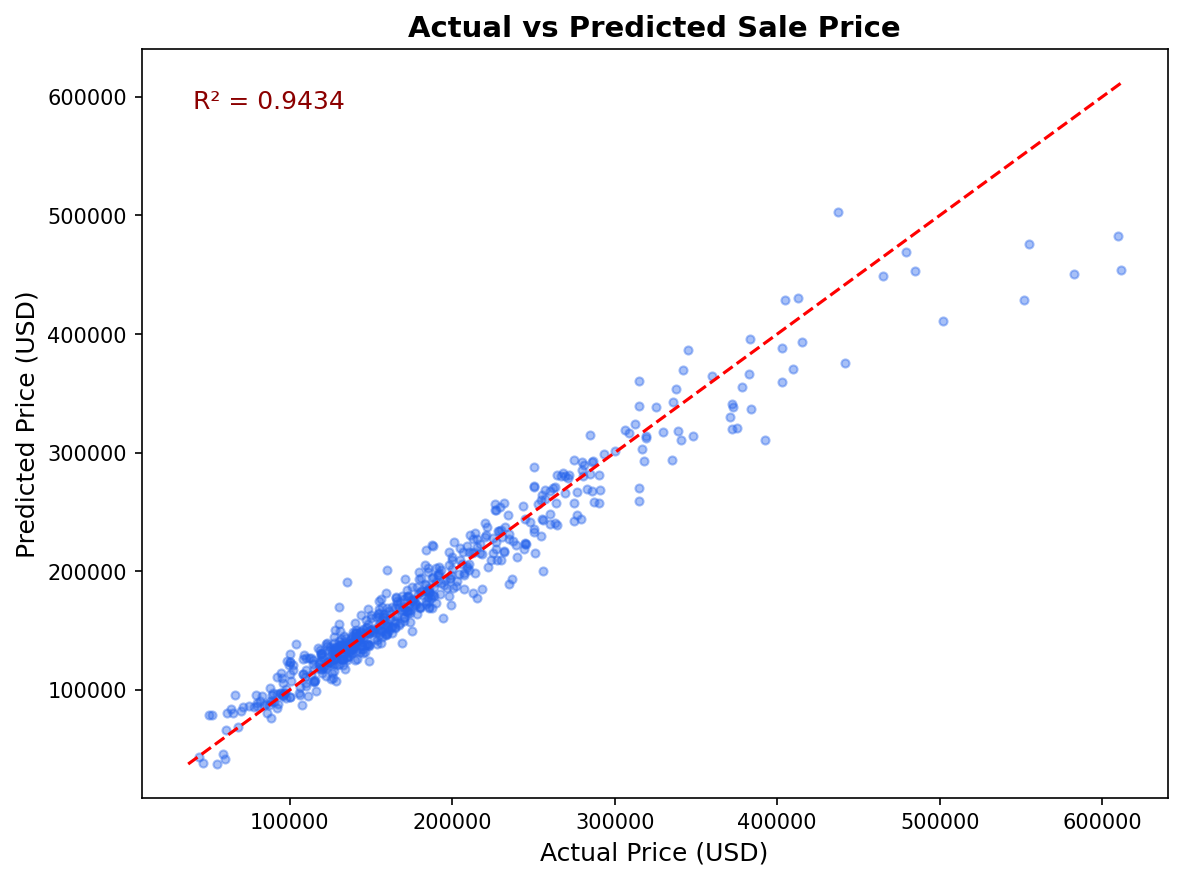

In [3]:
Image("../models/plots/actual_vs_predicted.png", width=700)

### Feature importance

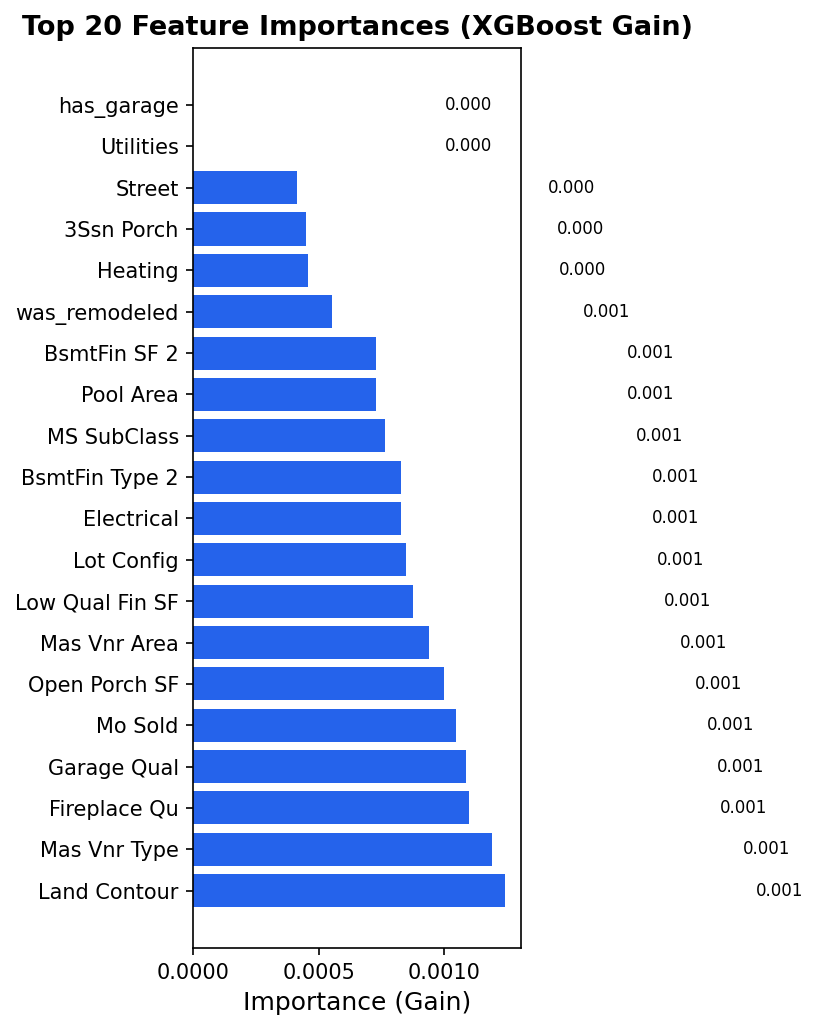

In [4]:
Image("../models/plots/feature_importance.png", width=700)

### Testing the predict function

In [5]:
from src.ml.predict import predict_price

# Example: 3 bed, 2 bath, 1500 sqft, quality 7, built 1990
result = predict_price({
    "Gr Liv Area":        1500,
    "Overall Qual":       7,
    "house_age":          34,
    "total_bathrooms":    2.0,
    "Bedroom AbvGr":      3,
    "Garage Cars":        2,
    "has_garage":         1,
    "total_finished_area": 1500,
    "qual_x_area":        10500,
    "overall_qual_squared": 49,
    "Fireplaces":         1,
    "central_air":        1,
})

print(f"Predicted Price:  ${result['predicted_price']:,.2f}")
print(f"Confidence Range: ${result['confidence_range']['low']:,.2f} – ${result['confidence_range']['high']:,.2f}")
print(f"Model R²:         {result['r2_score']}")

INFO:src.ml.predict:Loading model from disk ...
INFO:src.ml.predict:Model loaded. Version: v1.0 | R²: 0.94


Predicted Price:  $130,348.81
Confidence Range: $117,313.93 – $143,383.69
Model R²:         0.94


## SHAP Explanation

### What SHAP Tells Us

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value 
for each individual prediction.

- **Red dots** = high feature value; **Blue dots** = low feature value
- **X-axis position** = how much that feature pushed the price up or down

Key findings:
1. `Overall Qual` has the largest impact, high quality pushes price up significantly.
2. `qual_x_area` (engineered interaction feature) is top 5, proves feature engineering worked.
3. `house_age` pushes price down, older homes are cheaper, as expected.
4. `Neighborhood` encodes strong location premium
5. `Gr Liv Area` alone is less predictive than its interaction with quality